# Проект. Исследование стартапов

## Введение

### Цель и задачи проекта

**Цель:** исследовать закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Задачи:**
1. Загрузить данные и познакомиться с из содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
   - изучить данные более детально;
   - определить зависимости между данными.
4. Сформулировать выводы по проведенному анализу.

### Содержимое проекта

1. Загрузка данных и предобработка.
2. Инжиниринг признаков.
3. Работа с выбросами и анализ.
4. Анализ динамики.
5. Итоговый вывод и рекомендации.

## Шаг 1. Загрузка данных и предобработка

Датасеты получены из базы данных стартапов, предоставленной в рамках программы Яндекс Практикума.

* `cb_investments.zip` - содержит информацию о компаниях и их финансировании.

* `cb_returns.csv`- содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Исходные файлы с данными не включены в репозиторий.

### 1.1. Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные из датасетов cb_investments.csv и cb_returns.csv
# Для воспроизведения анализа необходимо загрузить данные локально.
df = pd.read_csv("datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv("datasets/cb_returns.csv")

In [3]:
# Выводим информацию из датафрейма на экран
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
# Показать все столбцы без ограничений
pd.set_option('display.max_columns', None)
# Ширина строки без ограничений
pd.set_option('display.width', None)  

# Выводим первые строки датафрейма на экран
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выводим информацию из датафрейма на экран
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [6]:
# Выводим первые строки датафрейма на экран
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

После первичного анализа можно сделать следующие выводы:
- Названия столбцов приведены к одному виду, но есть конечные пробелы, которые следует удалить.
- Все представленные данные имеют тип данных `float64` - 24 столбца, `object` - 16 столбцов. 
  - В столбце `funding_total_usd` представлена информация об общем объёме привлечённых инвестиций в долларах США, которая представлена типом данных `object`, однако для таких данных лучше использовать `float64`, но перед преобразованием типа нужно удалить запятые для выделения разрядов.
  - В столбце `funding_rounds` представлена информация об общем числе раундов финансирования, для которой лучше использовать тип данных `int64` и можно его оптимизировать. Также для столбца `participants` лучше использовать тип данных `int64` и можно его оптимизировать.
  - Для столбцов `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at` лучше использовать тип данных `datetime64`.
  - Для столбца `founded_year` лучше использовать тип данных `int64`.
  - Для столбцов `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`, `round_A`, `round_B`, `round_C`, `round_D`, `round_E`, `round_F`, `round_G`, `round_H` можно оптимизировать тип данных `float64`.
- Пропуски содержатся во всех столбцах с данными.
- Судя по первому знакомству с данными, значения в столбцах соответствуют их описанию.

Датасет `cb_returns` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа можно сделать следующие выводы:
- Названия столбцов приведены к одному виду.
- Все представленные данные имеют тип данных `float64` - 13 столбцов, `int64` - 1 столбец. Для столбцов `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding`,  можно оптимизировать тип данных `float64`.
- Пропусков в данных нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют их описанию.

In [7]:
# Создадим копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
df_copy = df.copy() 
len(df_copy)

54294

### 1.2. Предобработка данных

Проведем необходимые преобразования, чтобы подготовить данные для анализа.

In [8]:
# Убираем пробелы в начале и конце названий всех столбцов
df.columns = df.columns.str.strip()
print(df.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')


In [9]:
# Заменяем запятые, разделяющие разряды
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')
# Преобразовываем тип данных столбца funding_total_usd к типу float64, используя параметр errors для обработки ошибок
# с аргументом coerce, который заменит на NaN все данные, которые не удалось преобразовать в числа
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [10]:
# Преобразовываем тип данных столбцов к типу datetime64, используя параметр errors для обработки ошибок
# с аргументом coerce, который заменит на NaN все данные, которые не удалось преобразовать в числа
for column in ['founded_at', 'founded_month', 'founded_quarter', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df[column] = pd.to_datetime(df[column], errors='coerce')

In [11]:
# Преобразуем тип данных для столбцов
for column in ['founded_year', 'funding_rounds', 'participants']:
    df[column] = df[column].astype('Int64')

In [12]:
# Проверяем типы после преобразований
df.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                   Int64
participants                     Int64
founded_at              datetime64[ns]
founded_month           datetime64[ns]
founded_quarter         datetime64[ns]
founded_year                     Int64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

In [13]:
# Столбец year сделаем индексом
df_returns = df_returns.set_index('year')

display(df_returns)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [14]:
# Функция для отображения статистики пропусков
def show_missing_stats(tmp):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Тип данных': tmp.dtypes,
        'Кол-во пропусков': tmp.isnull().sum(),
        'Доля пропусков': tmp.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Тип данных,Кол-во пропусков,Доля пропусков
name,object,4857,0.0895
homepage_url,object,8305,0.1530
category_list,object,8817,0.1624
market,object,8817,0.1624
funding_total_usd,float64,13387,0.2466
status,object,6170,0.1136
country_code,object,10129,0.1866
state_code,object,24133,0.4445
region,object,10129,0.1866
city,object,10972,0.2021


In [15]:
# Заменим пропуски в текстовых столбцах на uknown
for column in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    df[column] = df[column].fillna('uknown')

### Удаление дубликатов

In [16]:
# Проверим полные дубликаты в датафрейме df
df.duplicated().sum()

4855

In [17]:
# Удаляем полные дубликаты в датафрейме df
df.drop_duplicates(keep='first', inplace=True)

In [18]:
# Проверим полные дубликаты в датафрейме df_returns
df_returns.duplicated().sum()

0

In [19]:
# Проверим уникальные значения в столбцах
for column in ['name', 'homepage_url', 'category_list', 'status', 'country_code', 'state_code', 'region', 'city']:
    print(df[column].unique(), '\n')

['Harvard University' 'University of New Brunswick' 'DuPont' ...
 'DigiByte' 'Xeltis' 'Logovers'] 

['http://harvard.edu' 'http://www.unb.ca' 'http://www.dupont.com' ...
 'http://digibyte.co' 'http://xeltis.com' 'http://www.logovers.com/'] 

['|Education|' 'uknown'
 '|Business Services|Agriculture|Automotive|Investment Management|' ...
 '|Medical|Information Services|Information Technology|'
 '|Mining Technologies|' '|Incubators|Designers|Entrepreneur|Startups|'] 

['operating' 'acquired' 'uknown' 'closed'] 

['USA' 'uknown' 'DEU' 'JPN' 'CAN' 'IND' 'CHE' 'PHL' 'ISR' 'ITA' 'GBR'
 'ESP' 'DNK' 'BEL' 'MEX' 'VNM' 'NLD' 'BRA' 'AUS' 'IRL' 'FRA' 'KHM' 'SWE'
 'FIN' 'KOR' 'KEN' 'TWN' 'THA' 'AUT' 'ZAF' 'NOR' 'EGY' 'CHN' 'PAK' 'SGP'
 'URY' 'ARE' 'CZE' 'NZL' 'TUR' 'RUS' 'COL' 'NGA' 'MCO' 'MYS' 'LUX' 'LTU'
 'PRT' 'HKG' 'BGR' 'SVK' 'EST' 'ISL' 'GHA' 'POL' 'BMU' 'JOR' 'LVA' 'TUN'
 'HUN' 'IDN' 'ARG' 'MAF' 'ROM' 'MLT' 'CYP' 'UKR' 'PAN' 'TZA' 'GRC' 'BWA'
 'ARM' 'CYM' 'HRV' 'SRB' 'CHL' 'UZB' 'SLV' 'MKD' '

In [20]:
# Убираем конечные пробелы в столбце
df['market'] = df['market'].str.strip()

### Фильтрация данных для анализа

Удаляем строки с критическими пропусками и компании, по которым нет информации о финансировании.

In [21]:
# Удаляем строки, где funding_total_usd пропущен
df = df.dropna(subset=['funding_total_usd'])
# Удаляем строки, где funding_rounds пропущен
df = df.dropna(subset=['funding_rounds'])
# Удаляем строки, где все финансовые столбцы NaN
df = df.dropna(subset=['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 
                       'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 
                       'product_crowdfunding'])

In [22]:
# Удалим пропуски в столбцах first_funding_at и last_funding_at для расчета mid_funding_at
df = df.dropna(subset=['first_funding_at', 'last_funding_at'])

### Восстановление данных о среднем раунде
Для компаний, у которых пропущена дата среднего раунда `mid_funding_at`, рассчитаем ее как середину между первым и последним раундом финансирования.

In [23]:
# Функция для вычисления середины интервала между первым и последним раундом
def calc_mid_date(row):
    days_diff = row['last_funding_at'] - row['first_funding_at']
    if days_diff.days > 0:
        return row['first_funding_at'] + days_diff / 2
    elif days_diff.days == 0:
        return row['first_funding_at']
    else:
        return pd.NaT
    
df['mid_funding_at'] = df.apply(calc_mid_date, axis=1)

In [25]:
# Оставшиеся пропуски в столбцах после преобразований
show_missing_stats(df)

,Тип данных,Кол-во пропусков,Доля пропусков
participants,Int64,13575,0.3319
founded_at,datetime64[ns],8707,0.2129
founded_month,datetime64[ns],8772,0.2144
founded_quarter,datetime64[ns],8772,0.2144
founded_year,Int64,8706,0.2128


- Столбец `participants` можно оставить как есть, так как он не используется в основных задачах.
- Пропуски в столбцах `founded_at`, `founded_month`, `founded_quarter`, `founded_year` можно оставить как есть, однако если они требуются , то можно заполнить пропуски на основе других данных (средним значением или медианой).

In [26]:
# Выводим информацию о кол-ве и проценте удаленных строк
old_rows = df_copy.shape[0]
new_rows = df.shape[0]
print(f"Исходное количество строк: {old_rows}")
print(f"Конечное количество строк: {new_rows}")
print(f"Удалено строк: {old_rows - new_rows}")
print(f"Процент удалённых строк: {(old_rows - new_rows)/old_rows*100:.2f}%")

Исходное количество строк: 54294
Конечное количество строк: 40905
Удалено строк: 13389
Процент удалённых строк: 24.66%


В результате предобработки данных были выполнены следующие действия:
- Привели столбцы в датафрейме `df` к одному виду, удалив конечные пробелы.
- Изменили тип данных в столбце `funding_total_usd` на `float64`. Тип данных столбцов `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at`, `last_funding_at` изменили на `datetime64`. Также изменили тип данных в столбцах `founded_year`, `funding_rounds`, `participants` на `Int64`.
- В датафрейме `df_returns` столбец `year` сделали индексом.
- Заменили пропуски в текстовых столбцах `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city` на значение `uknown`.
- Проверили данные на наличие полных дубликатов. В датафрейме `df` было обнаружено и удалено 4855 строк. Также удалили строки с пропусками в столбцах `funding_total_usd`, `funding_rounds` и строки, где все финансовые столбцы NaN. В итоге удалили 13389 строк, осталось 40905, процент удалённых строк: 24.66%.
- Пропуски в столбце `mid_funding_at` заменили на середину интервала между `first_funding_at` и `last_funding_at`, удалив перед этим пропуски в столбцах `first_funding_at` и `last_funding_at`. Также оставили данные только за 2000-2014 года.

Можно сказать, что оставшихся данных достаточно для решения дальнейших задач.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Для анализа стратегий привлечения инвестиций разделим компании на три группы на основе временного интервала между первым и последним раундом:

* Единичное финансирование — был всего один раунд финансирования.
* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
* Срок финансирования более года.

Визуализация этих групп по количеству компаний и объему привлеченных средств позволяет оценить, где концентрируется капитал и какие стратегии преобладают.

In [27]:
# Функция для определения группы по срокам финансирования
def groups_financing(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif (row['last_funding_at'] - row['first_funding_at']).days <= 366:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df['financing_group'] = df.apply(groups_financing, axis=1)

#### Визуализация распределения компаний по группам

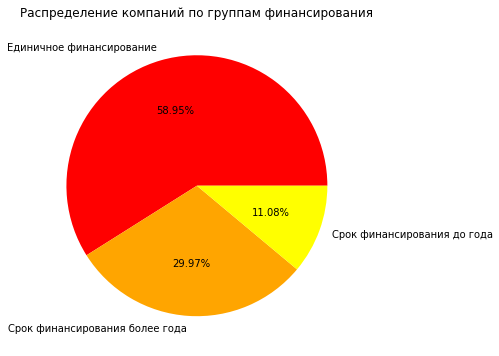

In [28]:
# Распределение компаний по группам финансирования
fin_gr_df = df.groupby('financing_group')['name'].count()

# Круговая диаграмма
plt.figure(figsize=(8, 6))
fin_gr_df.plot(kind='pie', autopct='%.2f%%', colors=['red', 'orange', 'yellow'])
plt.title('Распределение компаний по группам финансирования')
plt.ylabel('')
plt.show()

#### Визуализация доли инвестиций по группам

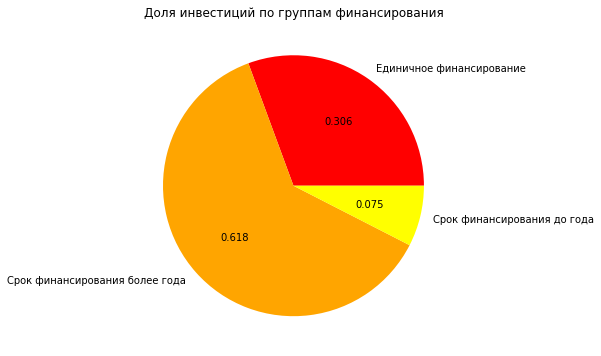

In [29]:
# Форматирует проценты в десятичные дроби
def format_as_decimal(pct):   
    return f'{pct/100:.3f}'

# Общий объем инвестиций
fin_total = df['funding_total_usd'].sum()
# Объем инвестиций по группам финансирования
fin_total_df = df.groupby('financing_group')['funding_total_usd'].sum() / fin_total

# Круговая диаграмма
plt.figure(figsize=(8, 6))
fin_total_df.plot(kind='pie', autopct=format_as_decimal, colors=['red', 'orange', 'yellow'])
plt.title('Доля инвестиций по группам финансирования')
plt.ylabel('')
plt.show()

Исходя из диаграммы "Распределение компаний по группам финансирования", видно, что 58.95% занимают компании с единичным финансированием, что может говорить о большом количестве стартапов, которые не получают повторного финансирования. На втором месте компании со сроком финансирования более года - 29.97%, что указывает на наличие компаний с долгосрочными перспективами. На третьем компании со сроком финансирования до года - 11.08%, что может говорить о быстром переходе компаний либо к долгосрочному финансированию, либо к единичному.

Из диаграммы "Доля инвестиций по группам финансирования" видно, что 0.618 занимают компании со сроком финансирования более года, это более половины всех инвестиций, что может говорить о состоятельности компаний, которые прошли проверку рынком и инвесторами. На втором месте компании с единичным финансированием 0.306, такой результат может быть связан с тем, что небольшие инвестиции даются многим компаниям в поисках лучшего вложения. На третьем компании со сроком финансирования до года - 0.075, эту стадию проходят достаточно быстро, переходя к единичному или долгосрочному финансированию.

### 2.2 Выделение средних и нишевых сегментов рынка

Для анализа рынка классифицируем сегменты (столбец `market`) на три категории по числу компаний в них:

* Массовые: > 120 компаний.
* Средние: от 35 до 120 компаний.
* Нишевые: < 35 компаний.

In [30]:
# Рассчитываем количество сегментов, отфильтруем пустые значения
market_df = df[df['market'] != 'uknown']['market'].value_counts().reset_index()
market_df.columns = ['market', 'company_count']

# Функция для распределения количества сегментов по категориям
def category_market(value):
    if value < 35:
        return 'нишевые'
    elif value <= 120:
        return 'средние'
    else:
        return 'массовые'

market_df['cat_market'] = market_df['company_count'].apply(category_market)
print(market_df)

              market  company_count cat_market
0           Software           4812   массовые
1      Biotechnology           3590   массовые
2             Mobile           2344   массовые
3         E-Commerce           1866   массовые
4        Curated Web           1693   массовые
..               ...            ...        ...
389    Mobile Health              1    нишевые
390          Tablets              1    нишевые
391       Web Design              1    нишевые
392      Data Mining              1    нишевые
393  Interior Design              1    нишевые

[394 rows x 3 columns]


#### Визуализация распределения сегментов

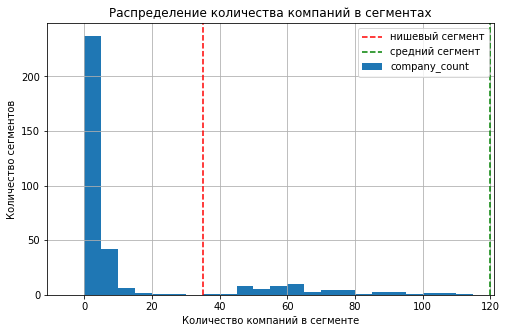

In [31]:
market_df.plot(
    kind='hist',
    bins=range(-5, 120, 5), 
    figsize = (8, 5)
)
plt.axvline(35, color='red', linestyle='--', label='нишевый сегмент')
plt.axvline(120, color='green', linestyle='--', label='средний сегмент')
plt.title('Распределение количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.grid()
plt.show()

#### Анализ распределения сегментов

Для упрощения дальнейшего анализа заменим названия средних и нишевых сегментов на общие метки `mid` и `niche`, оставляя массовые сегменты с их оригинальными названиями.

In [32]:
market_df.columns = ['market', 'company_count', 'cat_market']
# Создаем словарь
segment_cat_dict = dict(zip(market_df['market'], market_df['cat_market']))

# Функция для замены значений с столбце market в соответствии с категорией сегмента
def market_segment(segment_name):
    category = segment_cat_dict.get(segment_name)
    if category == 'массовые':
        return segment_name
    elif category == 'средние':
        return 'mid'
    elif category == 'нишевые':
        return 'niche'
    else:
        return 'other'
    
df['market'] = df['market'].apply(market_segment)
print(df['market'])

0        Education
1            other
2              mid
3        Education
4        Education
           ...    
49433        other
49434        niche
49435        other
49436        other
49437     Startups
Name: market, Length: 40905, dtype: object


Исходя из гистрограммы распределения количества компаний в сегментах, видно явное преобладание нишевых сегментов рынка. У 0-5 компаний более 200 сегментов. Зеленой линией отмечена граница средних сегментов, таких сегментов на графике очень мало. Сегменты либо остаются нишевыми, либо переходят в массовые.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализ типичных и аномальных объемов финансирования

Определим типичный для рынка размер общего финансирования (`funding_total_usd`). Для этого проанализируем описательную статистику и построим диаграмму размаха, чтобы визуально оценить распределение и выявить выбросы.

In [33]:
# Вывод описательное статистики
df['funding_total_usd'].describe()

count    4.090500e+04
mean     1.591247e+07
std      1.686829e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

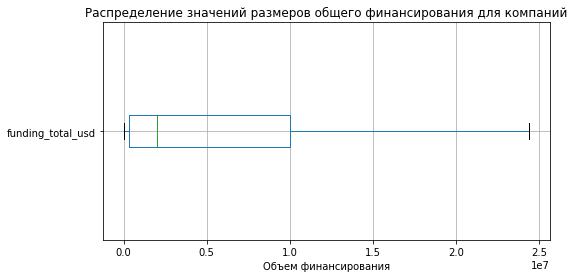

In [34]:
# Строим диаграмму размаха значений в столбце
plt.figure(figsize=(8, 4))
df.boxplot(
    column='funding_total_usd',
    vert=False,
    showfliers=False
)
plt.title('Распределение значений размеров общего финансирования для компаний')
plt.xlabel('Объем финансирования')
plt.show()

На графике видна несимметричность усов, что указывает на асимметрию распределения, на графике видно правоассиметричное распределение. Большинство данных лежат в интревале от 350000 до 10000000. Типичный размер финансирования на графике выделен зеленой линий - это медиана, её значение 2000000. Значения, лежащие выше 24475000 можно считать выбивающимися, но назвать аномалиями нельзя, так как существуют стартапы, в которые вкладываются большие инвестиции.

Используя метод межквартильного размаха (IQR) отдельно по каждому сегменту, определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование.

In [35]:
# Создаем серию из уникальных значений
markets_uniq = df['market'].unique()

# Создаем новый столбец для определения аномалий и заполняем сначала все значения False
df['anomaly'] = False

for market_type in markets_uniq:
    # Отбираем в датафрейм данные, соответствующие текущему значению market_type
    market_data = df[df['market'] == market_type]
    
    # Рассчитываем значения верхней и нижней границ из фильтрованного датафрейма
    q1 = market_data['funding_total_usd'].quantile(0.25)
    q3 = market_data['funding_total_usd'].quantile(0.75)
    IQR = q3 - q1
    upper = q3 + 1.5 * IQR
    down = q1 - 1.5 * IQR
    
    # Проверяем условия, если они выполняются, то считаем объем финансирования аномальным и меняем значение в anomaly на True
    df.loc[(df['market'] == market_type) & ((df['funding_total_usd'] < down) | (df['funding_total_usd'] > upper)),
           'anomaly'] = True

#### Топ-15 сегментов с наибольшей долей аномалий

In [36]:
# Выбираем топ-15 сегментов рынка с наибольшей долей компаний, получивших аномальное финансирование, предварительно отфильтровав
# значения other, т.к. это заглушка на пустые значения
top_anomaly = df[df['market'] != 'other'].groupby('market')['anomaly'].mean().sort_values(ascending=False).head(15)
print(top_anomaly)

market
Real Estate        0.172043
Entertainment      0.166667
Consulting         0.166189
Search             0.164948
Cloud Computing    0.164474
Photography        0.161765
SaaS               0.161765
Technology         0.159664
Video              0.159574
niche              0.159036
Travel             0.154545
Networking         0.153846
Internet           0.153527
Big Data           0.153333
Marketplaces       0.153061
Name: anomaly, dtype: float64


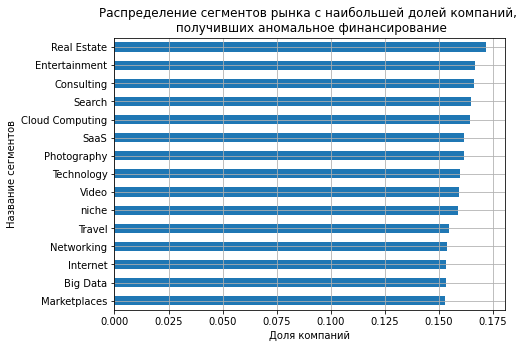

In [37]:
# Построим столбчатую диаграмму
top_anomaly.sort_values(ascending=True).plot(
    kind='barh',
    rot=0,
    title='Распределение сегментов рынка с наибольшей долей компаний, \n получивших аномальное финансирование',
    legend=False,
    figsize=(7, 5)
)

plt.ylabel('Название сегментов')
plt.xlabel('Доля компаний')
plt.grid()
plt.show()

Большая доля компаний, получивших аномальное финансирование, у сегментов `Real Estate` 17.2%, `Entertainment` 16.7% и `Consulting` 16.6%. Сегмент `Real Estate` связан с недвижимостью, возможно самый высокий показатель связан с наличием крупных инвесторов. Технологический сектор доминирует в списке, но не является абсолютным лидером, хотя `Search`, `Cloud Computing`, `SaaS` и `Big Data` ожидаемо присутствуют в топе. Также в топ-15 находится нишевый сегмент - 16.0% компаний получают аномальное финансирование, т.е. встречаются отдельные компании, привлекающие непропорционально большие инвестиции. Сегменты с высокой долей аномалий одновременно предлагают и большие возможности, и высокую конкуренцию за внимание инвесторов.

### 3.2 Определение границ периода и финальная фильтрация

Для анализа динамики возьмем период с 2000 по 2014 год, так как именно в эти годы данные наиболее полны и релевантны.

In [38]:
# Минимальная дата в 2014 году
min_2014 = df[df['last_funding_at'].dt.year == 2014]['last_funding_at'].min()

# Максимальная дата в 2014 году
max_2014 = df[df['last_funding_at'].dt.year == 2014]['last_funding_at'].max()

first_max_2014 = df[df['first_funding_at'].dt.year == 2014]['first_funding_at'].max()

mid_max_2014 = df[df['mid_funding_at'].dt.year == 2014]['mid_funding_at'].max()

print(f"Первая дата в 2014: {min_2014}")
print(f"Последняя дата в 2014: {max_2014}")
print(first_max_2014)
print(mid_max_2014)

# Количество данных в каждом месяце в 2014 году
month_cnt = df[df['last_funding_at'].dt.year == 2014]['last_funding_at'].dt.month.value_counts().sort_index()
print(f"Количество записай по месяцам:\n{month_cnt}")

# Создаём датафрейм, чтобы посмотреть соизмеримость количества данных по годам
table = pd.DataFrame({
    'last_by_year': df['last_funding_at'].dt.year.value_counts().sort_index(),
    'first_by_year': df['first_funding_at'].dt.year.value_counts().sort_index(),
    'mid_by_year': df['mid_funding_at'].dt.year.value_counts().sort_index()}
)
print(table)

Первая дата в 2014: 2014-01-01 00:00:00
Последняя дата в 2014: 2014-12-31 00:00:00
2014-12-31 00:00:00
2014-12-31 00:00:00
Количество записай по месяцам:
1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1134
10    1139
11     732
12      52
Name: last_funding_at, dtype: int64
      last_by_year  first_by_year  mid_by_year
1921             1              1            1
1960             1              2            1
1979             1              1            1
1982             3              3            3
1983             1              1            2
1984             1              1            1
1985             3              4            3
1987             2              2            2
1989             1              1            1
1990             1              3            1
1992             3              4            3
1993             1              1            2
1994             5              5            4
1995             2  

Можно сказать, что данные были предоставлены полные за 2014 год. В сравнении с другими годами видно, что данных по 2014 году больше всего. Так же стоит отметить, что за 1921-1999 предоставлены единичные данные, их стоит исключить при дальнейшей обработке.

In [39]:
# Оставим данные только за 2000-2014 года
df = df[(df['mid_funding_at'].dt.year >= 2000) & (df['mid_funding_at'].dt.year <= 2014)]

In [40]:
# Исключим из анализа компании, помеченные как аномалии
df = df[df['anomaly'] != True]

# Проверим, что во все годы было >= 50 раундов финансирования
rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()
print(rounds_by_year)

mid_funding_at
2000       75
2001       66
2002       57
2003       90
2004      167
2005      850
2006     1495
2007     2062
2008     2856
2009     4005
2010     5957
2011     8176
2012    10916
2013    12927
2014     8244
Name: funding_rounds, dtype: Int64


Во все года с 2000 по 2014 было зафиксировано более 50 раундов финансирования

### 3.3. Анализ типов финансирования по объёму и популярности

Проанализируем различные типы финансирования (посевное, венчурное, гранты и т.д.) по двум параметрам: общий привлеченный объем и количество компаний, использующих данный тип.

In [41]:
# Создаем датафрейм с типами финансирования
df_filter = df[df_returns.columns]

# Сумма привлеченных средств по каждому типу
# Функция для расчёта суммы значений в столбце
def calc(column):
    return column.sum()

type_sum = df_filter.apply(calc, axis=0)
print(type_sum.sort_values(ascending=False))

venture                 1.291282e+11
seed                    9.438636e+09
debt_financing          8.178503e+09
private_equity          4.828109e+09
angel                   2.481414e+09
undisclosed             2.100352e+09
grant                   1.978849e+09
post_ipo_equity         1.946452e+09
convertible_note        5.660394e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.379606e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64


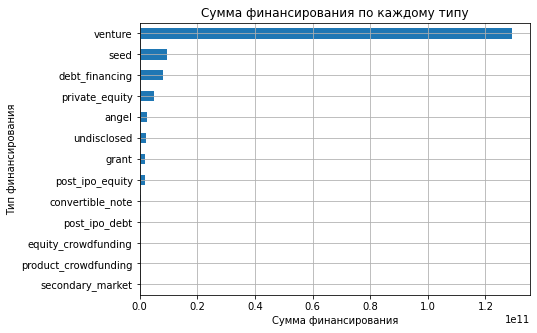

In [42]:
# Строим столбчатую диаграмму
type_sum.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(7, 5),
    title='Сумма финансирования по каждому типу',
    legend=False
)
plt.xlabel('Сумма финансирования')
plt.ylabel('Тип финансирования')
plt.grid()
plt.show()

In [43]:
# Популярность типов: количество компаний, использовавших тип (>0)
# Функция для расчёта количества ненулевых значений в столбце
def calc(column):
    return (column > 0).sum()

type_cnt = df_filter.apply(calc, axis=0)
print(type_cnt.sort_values(ascending=False))

venture                 18826
seed                    13378
debt_financing           3266
angel                    2937
grant                    1003
undisclosed               813
private_equity            634
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
dtype: int64


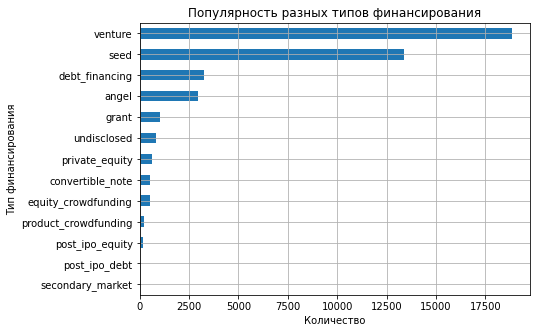

In [44]:
# Строим столбчатую диаграмму
type_cnt.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(7, 5),
    title='Популярность разных типов финансирования',
    legend=False
)
plt.ylabel('Тип финансирования')
plt.xlabel('Количество')
plt.grid()
plt.show()

Часто используемые, но с небольшими объёмами:
- `seed` — 13378 компаний (2-е место по популярности), но всего 9.4 млрд;
- `angel` — 2937 компаний, но всего 2.5 млрд (бизнес-ангелы инвестируют часто, но малыми суммами);
- `grant` — 1003 компании, 2.0 млрд (гранты распределяются широко, но суммы относительно скромные);
- `convertible_note` — 521 компаний, 566 млн (конвертируемые займы популярны, но объемы невысоки).

Редко встречающиеся, но с большими объёмами:
- `private_equity` — 634 компании, но 4.8 млрд (огромный объем при относительно небольшом количестве сделок);
- `debt_financing` — 3266 компаний, но 8.2 млрд (долговое финансирование: редкие, но очень крупные транши);
- `post_ipo_equity` — всего 164 компаний, 1.95 млрд;
- `post_ipo_debt` — всего 27 компаний, 287 млн;
- `secondary_market` — всего 7 компаний, 45 млн (самый редкий тип финансирования).

`venture` — 18826 компаний и 129.1 млрд:
- Лидер и по популярности, и по объему;
- Венчурное финансирование — основной драйвер рынка;
- Оптимальное сочетание массовости и масштаба.

#### Анализ возвратов инвестиций

Используя дополнительный датасет, проанализируем, какие типы финансирования приносят наибольший возврат.

In [45]:
# Функция для расчёта суммы значений в столбце
def calc(column):
    return column.sum()

type_sum = df_returns.apply(calc, axis=0)
print(type_sum.sort_values(ascending=False))

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


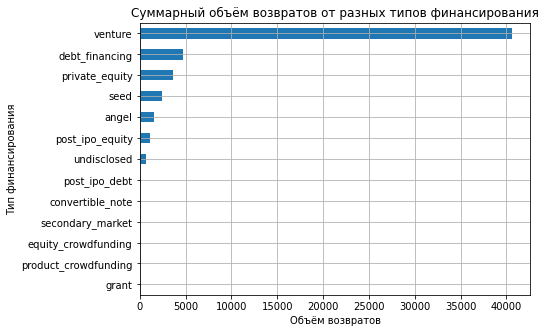

In [46]:
# Строим столбчатую диаграмму
type_sum.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(7, 5),
    title='Суммарный объём возвратов от разных типов финансирования',
    legend=False
)
plt.xlabel('Объём возвратов')
plt.ylabel('Тип финансирования')
plt.grid()
plt.show()

Лидер по возвратам — `venture` (40.6 млрд). Это составляет около 70% от всех возвращённых средств. Венчурное финансирование не только самое популярное и крупное по объёму, но и делает максимальный возврат для инвесторов. `debt_financing` (4.7 млрд) и `private_equity` (3.6 млрд) занимают второе и третье место: долговое финансирование и прямые инвестиции показывают высокую возвратность. `grant` (0.00) — гранты не возвращаются, что соответствует их природе безвозмездного финансирования.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Рассчитаем средний размер одного раунда для каждой компании (`avg_round_size`) и проанализируем, как менялись медианный размер раунда и общее количество раундов по годам.

In [47]:
# Рассичитываем средний объём раунда для каждой компании
df['avg_round_size'] = df['funding_total_usd'] / df['funding_rounds']

In [48]:
# Медианный размер раунда по годам
avg_round_by_year = df.groupby(df['mid_funding_at'].dt.year)['avg_round_size'].median()
print(avg_round_by_year)

mid_funding_at
2000         2000000.0
2001         2346791.0
2002         2420000.0
2003         1505000.0
2004         2950000.0
2005         5000000.0
2006         4000000.0
2007    2791666.666667
2008    2025603.666667
2009         1378185.4
2010         1200000.0
2011         1000000.0
2012          750000.0
2013          555000.0
2014          650000.0
Name: avg_round_size, dtype: Float64


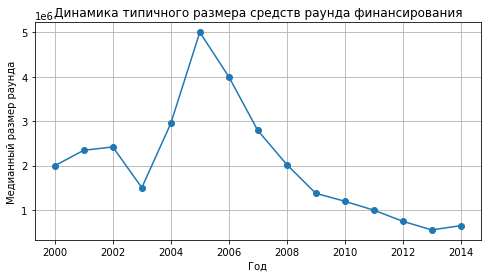

In [49]:
# Построим линейный график
avg_round_by_year.plot.line(
    avg_round_by_year.index, 
    avg_round_by_year,
    marker='o',
    figsize=(8, 4)
)

plt.title('Динамика типичного размера средств раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда')
plt.grid()
plt.show()

In [50]:
# Общее количество раундов по годам
total_rounds_by_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()
print(total_rounds_by_year)

mid_funding_at
2000       75
2001       66
2002       57
2003       90
2004      167
2005      850
2006     1495
2007     2062
2008     2856
2009     4005
2010     5957
2011     8176
2012    10916
2013    12927
2014     8244
Name: funding_rounds, dtype: Int64


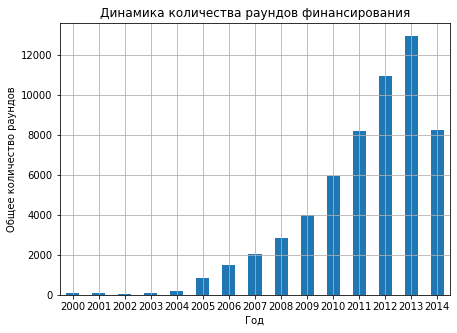

In [51]:
# Построим столбчатую диаграмму
total_rounds_by_year.plot(
    kind='bar',
    figsize=(7, 5),
    title='Динамика количества раундов финансирования',
    legend=False,
    rot=0
)
plt.xlabel('Год')
plt.ylabel('Общее количество раундов')
plt.grid()
plt.show()

Типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году и составил 5000000, после чего началось снижение показателя. По количеству раундов в 2014 году был спад, зафиксировано 8244 раундов, это значительно меньше, чем 2013 году. Также это резкое падение, после роста данного показателя с 2000 года. По размеру средств раунда также наблюдается снижение, в 2014 году типичный размер средств раунда составил 650000.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Построим сводную таблицу для анализа динамики суммарного объема финансирования по массовым сегментам рынка. Это позволит выявить, какие отрасли показывали устойчивый рост вплоть до 2014 года.

In [52]:
# Построим сводную таблицу
year = df['mid_funding_at'].dt.year
table = pd.pivot_table(
    df,
    index='market',
    columns=year,
    values='funding_total_usd',
    aggfunc='sum'
)
display(table)

mid_funding_at,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Advertising,8250000.0,14998321.0,NaN,17350000.0,16500000.0,7.870000e+07,1.408619e+08,3.967240e+08,4.901354e+08,6.133831e+08,6.211934e+08,6.475746e+08,7.214657e+08,5.216663e+08,2.413078e+08
Analytics,1200000.0,10774916.0,7500000.0,NaN,3000000.0,8.221100e+07,9.004949e+07,5.947454e+07,1.709459e+08,1.443519e+08,1.485341e+08,4.285416e+08,5.736992e+08,7.328840e+08,2.639131e+08
Apps,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.310600e+06,3.050000e+06,4.200000e+06,8.542779e+06,1.068574e+07,3.327908e+07,3.492900e+07,6.903773e+07
Automotive,NaN,NaN,NaN,4530000.0,NaN,NaN,1.146000e+07,2.260000e+07,5.258343e+07,3.152312e+07,3.274692e+07,9.339982e+07,5.184806e+07,9.234774e+07,8.095591e+07
Big Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.100000e+06,1.150000e+06,3.579890e+06,2.300000e+06,2.696916e+07,1.141936e+08,1.167019e+08,8.578260e+07
Biotechnology,NaN,NaN,NaN,25262631.0,122766544.0,4.096895e+08,9.082696e+08,1.065529e+09,1.077233e+09,2.991629e+09,4.442114e+09,6.103610e+09,6.221828e+09,5.334473e+09,3.197061e+09
Clean Technology,NaN,NaN,NaN,NaN,NaN,2.159500e+07,2.032806e+08,5.316336e+08,2.105767e+09,1.305968e+09,2.241300e+09,1.997123e+09,1.669981e+09,1.345343e+09,7.428884e+08
Cloud Computing,11500000.0,NaN,NaN,NaN,NaN,4.900000e+06,1.603546e+07,8.543430e+05,5.289135e+07,1.164856e+07,2.193570e+07,6.150660e+07,8.956638e+07,9.501178e+07,8.694086e+07
Consulting,4500000.0,NaN,NaN,NaN,NaN,4.486200e+07,2.396555e+07,6.999206e+07,3.006108e+07,6.101764e+07,5.561576e+07,4.445561e+07,7.811525e+07,8.928163e+07,6.180394e+07


In [53]:
# Отбираем данные, где сегменты показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013
market_by_year = table.loc[table[2013] < table[2014]]
display(market_by_year)

mid_funding_at,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Apps,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1310600.0,3050000.0,4200000.0,8542779.0,10685736.0,3.327908e+07,3.492900e+07,6.903773e+07
Design,NaN,NaN,NaN,NaN,NaN,9300000.0,707000.0,10800000.0,344302.0,2150144.0,8669655.0,19031825.0,3.571793e+07,6.883776e+07,6.906082e+07
Entertainment,100000.0,NaN,NaN,NaN,NaN,27450000.0,1800000.0,15524025.0,20650000.0,22269585.0,3847608.0,46716762.0,2.619277e+07,5.955814e+07,7.520818e+07
Internet,10000000.0,NaN,1100000.0,NaN,NaN,12275000.0,5000.0,540000.0,26388343.0,21925773.0,26978058.0,38371042.0,6.398828e+07,5.944993e+07,1.178308e+08
Manufacturing,56659310.0,2368582.0,NaN,4269608.0,29000000.0,50660000.0,90379529.0,153190008.0,123868732.0,352719349.0,316173065.0,564948500.0,5.649467e+08,3.857827e+08,4.791450e+08
Marketplaces,NaN,105000.0,NaN,NaN,NaN,NaN,NaN,NaN,3885720.0,550000.0,4805949.0,11646932.0,2.237144e+07,4.025689e+07,4.121734e+07
Medical,24000000.0,NaN,NaN,NaN,NaN,11090000.0,20250000.0,2100000.0,28812744.0,13805120.0,12376418.0,9379931.0,6.738963e+07,7.014134e+07,1.763501e+08
Photography,NaN,NaN,NaN,NaN,7100000.0,2000000.0,11686406.0,10764586.0,23659381.0,12922378.0,30159227.0,11966017.0,6.689752e+07,4.773298e+07,5.529785e+07
SaaS,NaN,NaN,NaN,NaN,NaN,7240000.0,4069241.0,4957000.0,15200068.0,33559012.0,14056812.0,41923922.0,5.508270e+07,7.541811e+07,1.028578e+08


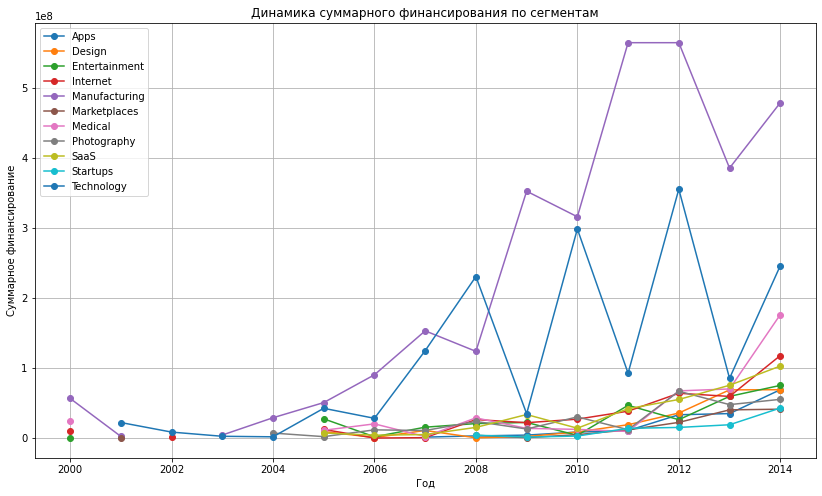

In [54]:
# Удаляем строки с индексами mid, niche, other
market_by_year = market_by_year.drop(['mid', 'niche', 'other'], errors='ignore')

# Строим ленейчатый график для каждого сегмента по годам
plt.figure(figsize=(14, 8))
for segment in market_by_year.index:
    plt.plot(market_by_year.columns, market_by_year.loc[segment], marker='o', label=segment)

plt.title('Динамика суммарного финансирования по сегментам')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование')
plt.legend()
plt.grid()
plt.show()

Сегменты с нестабильной динамикой:
- `Technology`. Колебания: от 230 млн в 2008 до 85 млн в 2013 и снова рост до 246 млн в 2014.
- `Manufacturing`. Крупнейший сегмент, но спад в 2013-2014. Рост замедлился, хотя объемы остаются высокими.

Сегменты с наиболее быстрым и уверенным ростом:
- `Medical`. Рост с 24 млн в 2000 до 176 млн в 2014, стабильная положительная динамика.
- `Apps`. С нуля в 2000-2004 до 69 млн в 2014. Непрерывный рост с 2007 года.
- `Design` — стабильный восходящий тренд. С 0.7 млн в 2006 до 69 млн в 2014. Нет спадов, только рост год к году.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для оценки эффективности инвестиций проанализируем, какая часть вложенных средств возвращается инвесторам. Рассчитаем нормированные значения возврата (отношение возврата к объему инвестиций) по годам и типам финансирования.

In [55]:
# Группируем объем инвестиций по годам и типам
columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
        'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

type_by_year = df.groupby(df['mid_funding_at'].dt.year)[columns].sum()

# Рассчитываем долю возврата (добавляем 1e-60 к знаменателю для избежания деления на ноль)
perc = df_returns / (type_by_year + 1e-60)
display(perc)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.552169e-06,2.694075e-07,0.000000e+00,6.970424e-07,0.000000e+00,2.165000e-06,2.723422e-07,0.0,0.000000e+00,9.400000e+59,0.000000e+00,2.000000e+59,0.000000e+00
2001,3.384943e-07,1.546162e-07,0.000000e+00,3.875090e-07,1.000000e+58,8.552381e-07,1.119574e-06,0.0,0.000000e+00,4.600000e+59,0.000000e+00,4.600000e+59,0.000000e+00
2002,9.495415e-07,1.444923e-06,0.000000e+00,1.150446e-06,2.000000e+58,3.420000e+60,3.410000e-06,0.0,2.013333e-07,1.133333e-06,0.000000e+00,6.000000e+58,0.000000e+00
2003,1.332091e-06,8.225360e-07,0.000000e+00,5.612213e-07,1.000000e+58,2.505747e-07,5.166667e-07,0.0,1.620000e+60,2.110000e+60,0.000000e+00,8.000000e+58,0.000000e+00
2004,5.363298e-07,8.317406e-07,0.000000e+00,5.623751e-07,1.478014e-09,4.927273e-07,1.390256e-06,0.0,1.825000e-07,3.380000e+60,0.000000e+00,5.500000e+59,0.000000e+00
2005,9.387876e-07,5.461840e-07,0.000000e+00,2.747858e-06,2.000000e+58,1.164480e-06,7.734295e-07,0.0,2.400000e+60,3.510000e+60,0.000000e+00,5.000000e+58,0.000000e+00
2006,1.123087e-06,3.716502e-07,1.900000e+59,1.436333e-06,1.780000e+60,1.317629e-06,8.924927e-07,0.0,6.579456e-06,5.934689e-06,0.000000e+00,1.554632e-08,0.000000e+00
2007,4.710136e-07,3.984756e-07,1.000000e+58,5.492264e-07,5.441272e-07,9.751274e-07,1.072223e-06,0.0,1.218686e-06,2.436000e+61,0.000000e+00,5.700000e+59,0.000000e+00
2008,3.762730e-07,2.436924e-07,3.215238e-08,6.620298e-07,1.531467e-07,1.144854e-06,4.588190e-07,0.0,9.026030e-07,8.428000e+61,0.000000e+00,4.700000e+59,0.000000e+00


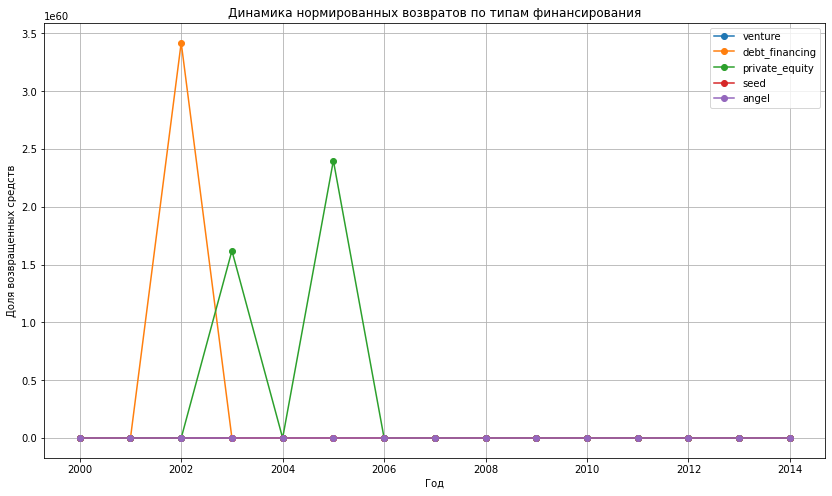

In [56]:
column = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
# Строим ленейчатый график
plt.figure(figsize=(14, 8))
for segment in column:
    plt.plot(perc.index, perc[segment], marker='o', label=segment)

plt.title('Динамика нормированных возвратов по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвращенных средств')
plt.legend()
plt.grid()
plt.show()

Вывод об устойчивости типов финансирования:
- `angel` — наиболее устойяивый рост. Демонстрирует стабильное увеличение доли возвратов с 2.72e-7 в 2000 до 1.04e-6 в 2014. Нет резких спадов, плавная положительная динамика.
- `primary_equity` — после 2006 года наблюдается четкий восходящий тренд. Рост с 6.58e-6 в 2006 до 8.57e-7 в 2014.
- `venture` — спад в 2006-2011, затем уверенный рост с 2012 года. В 2014 году показал максимум за последние 7 лет (6.53e-7)
- `debt_financing` — резкие скачки и падения (от 2.5e-7 до 3.4e+60).
- `seed` — стабильное снижение с 1.55e-6 в 2000 до 2.36e-7 в 2014.


## Шаг 5. Итоговый вывод и рекомендации

Необходимо было исследовать закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. В ходе исследования проанализировали 54294 строк данных, в которых представлена информация о компаниях и состоявшемся финансировании. После обработки пустых значений и дубликатов осталось 40905 строки. Также был обработан датасет с информацией об объёмах возвратов по годам и типам финансирования в миллионах долларов.

На основании исследования можно следать следующие выводы: 58.95% компаний имеют единичное финансирование, но получают лишь 30.6% инвестиций. 29.97% компаний с финансированием более года получают 61.8% всех инвестиций. 90% сегментов — нишевые (<35 компаний). Лишь 1-2% сегментов — массовые, но они содержат основную массу капитала. Компании либо остаются нишевыми, либо переходят в массовые. `venture` — абсолютный лидер по объему, популярности и возвратам (70% всех возвратов). В 2014 году происходит резкое падение количества раундов и размера раунда. Противоречие возникает на фоне того, что в 2014 году на рынке происходит спад, но некоторые сегменты продолжают расти. То есть рынок не находится в кризисе, а происходит его перестраение. Инвестиции переходят из застоявшихся сегментов в растущие.

Рекомендации заказчику:
- Лучшая отрасль для финансирования `medical`: наиболее быстрый и уверенный рост среди всех сегментов: с 24 млн (2000г) до 176 млн (2014г). Стабильная положительная динамика. Также можно рассмотреть `design`: ни одного годового спада.
- Наиболее уместный тип финансирования `venture`. Лидер по всем показателям: 18 826 компаний, 129.1 млрд инвестиций. Оптимальное сочетание массовости и масштаба. Лидер по возвратам: 40.6 млрд (70% всех возвращенных средств). Также можно рассмотреть `private_equity`: высокая возвратность 3.6 млрд, уверенный восходящий тренд с 2006 года.